# setup

In [1]:
!pip install -q --upgrade lightgbm
import lightgbm as lgb
print("lightgbm", lgb.__version__)

lightgbm 4.7.0


# get the data

In [2]:
from google.colab import files
files.upload()                      # pick kaggle.json

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle competitions download -c ieee-fraud-detection -p /content/data
!cd /content/data && unzip -oq ieee-fraud-detection.zip
!ls -la /content/data

Saving kaggle.json to kaggle.json
100% 118M/118M [00:00<00:00, 136MB/s]

total 1444184
drwxr-xr-x 3 root root      4096 Aug 20 12:42 .
drwxr-xr-x 1 root root      4096 Aug 20 12:42 ..
-rw-r--r-- 1 root root 123856947 Dec 11  2019 ieee-fraud-detection.zip
drwxr-xr-x 2 root root      4096 Aug 20 12:40 .ipynb_checkpoints
-rw-r--r-- 1 root root   6080314 Dec 11  2019 sample_submission.csv
-rw-r--r-- 1 root root  25797161 Dec 11  2019 test_identity.csv
-rw-r--r-- 1 root root 613194934 Dec 11  2019 test_transaction.csv
-rw-r--r-- 1 root root  26529680 Dec 11  2019 train_identity.csv
-rw-r--r-- 1 root root 683351067 Dec 11  2019 train_transaction.csv


# imports and config

In [27]:
import os, json, time, gc, warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ── COST MODEL: every number here is an ASSUMPTION. State this in your README.
# FN = fraud we let through -> we eat the full transaction amount.
# FP = good txn sent to review -> analyst time + customer-friction proxy.
REVIEW_COST   = 5.00
FRICTION_COST = 3.00
FP_COST       = REVIEW_COST + FRICTION_COST

ENTITY_COLS = ["card1", "addr1", "P_emaildomain"]
WINDOWS     = [3600, 86400, 7 * 86400]        # 1h, 24h, 7d

DATA_DIR    = "/content/data"
OUT_DIR     = "/content/results"
SAMPLE_FRAC = 1.0        # use 0.25 for a fast smoke test, 1.0 for the real run

os.makedirs(OUT_DIR, exist_ok=True)
print("config ready | FP_COST =", FP_COST)

config ready | FP_COST = 8.0


In [28]:
print(SAMPLE_FRAC)

1.0


# load

In [29]:
def load_data(data_dir, sample_frac=1.0):
    tx_path = os.path.join(data_dir, "train_transaction.csv")
    if not os.path.exists(tx_path):
        raise FileNotFoundError(f"Missing {tx_path}")
    print(f"[load] reading {tx_path} ...")
    df = pd.read_csv(tx_path)

    id_path = os.path.join(data_dir, "train_identity.csv")
    if os.path.exists(id_path):
        print(f"[load] merging {id_path} ...")
        df = df.merge(pd.read_csv(id_path), on="TransactionID", how="left")
    else:
        print("[load] train_identity.csv not found -- continuing without it.")

    if sample_frac < 1.0:
        # Sample by TIME BLOCK, not randomly, so temporal structure survives.
        cutoff = df["TransactionDT"].quantile(sample_frac)
        df = df[df["TransactionDT"] <= cutoff].copy()
        print(f"[load] sampled earliest {sample_frac:.0%} of the time range")

    for c in df.select_dtypes(include=["float64"]).columns:
        df[c] = df[c].astype(np.float32)

    df = df.sort_values("TransactionDT").reset_index(drop=True)
    print(f"[load] {len(df):,} rows | {df.shape[1]} cols | fraud {df['isFraud'].mean():.4%}")
    return df

df = load_data(DATA_DIR, SAMPLE_FRAC)
gc.collect()

[load] reading /content/data/train_transaction.csv ...
[load] merging /content/data/train_identity.csv ...
[load] 590,540 rows | 434 cols | fraud 3.4990%


4097

# leakage-safe velocity features + the unit test

In [30]:
def _window_counts(df, idx_map, window):
    """Prior txns for this entity within `window` seconds, current row excluded.

    df is globally time-sorted, so each group's times are ascending. Positions
    [left, i) are strictly before row i AND inside the window. NaN = entity key
    missing, which LightGBM routes natively -- do NOT fill with 0, since 0 means
    "first-ever transaction for this entity", a different and real state.
    """
    out = np.full(len(df), np.nan, dtype=np.float32)
    t_all = df["TransactionDT"].values
    for idx in idx_map.values():
        t = t_all[idx]
        left = np.searchsorted(t, t - window, side="left")
        out[idx] = np.arange(len(t)) - left
    return out


def add_velocity_features(df):
    print("[feat] building backward-looking entity-velocity features ...")
    for col in ENTITY_COLS:
        if col not in df.columns:
            continue
        g = df.groupby(col, sort=False)
        idx_map = g.indices                       # computed once, reused per window

        # cumcount() yields NaN where the group key is NaN -- keep it float.
        df[f"{col}__n_prior"] = g.cumcount().astype(np.float32)

        df[f"{col}__secs_since_prev"] = (
            df["TransactionDT"] - g["TransactionDT"].shift(1)).astype(np.float32)

        # Mean prior amount = (cumsum - current) / prior_count. Vectorised, no leak.
        csum = g["TransactionAmt"].cumsum() - df["TransactionAmt"]
        cnt  = df[f"{col}__n_prior"].replace(0, np.nan)
        df[f"{col}__prior_amt_mean"] = (csum / cnt).astype(np.float32)
        df[f"{col}__amt_vs_prior"] = (
            df["TransactionAmt"] / df[f"{col}__prior_amt_mean"]).astype(np.float32)

        for w in WINDOWS:
            df[f"{col}__cnt_{w}s"] = _window_counts(df, idx_map, w)

    df["hour"] = ((df["TransactionDT"] / 3600) % 24).astype(np.int8)
    df["dow"]  = ((df["TransactionDT"] / 86400) % 7).astype(np.int8)
    df["amt_log"] = np.log1p(df["TransactionAmt"]).astype(np.float32)
    df["amt_decimal"] = (
        df["TransactionAmt"] - df["TransactionAmt"].astype(int)).astype(np.float32)
    return df


def assert_no_future_leakage(df, n_checks=300, seed=0):
    """Recompute a feature by brute force and confirm it only saw the past.

    Note this checks FEATURE VALUES, not just that test timestamps exceed train
    timestamps -- the latter is guaranteed by the split and proves nothing.
    """
    print("[test] verifying features are strictly backward-looking ...")
    rng = np.random.default_rng(seed)
    col, w = ENTITY_COLS[0], WINDOWS[1]
    feat = f"{col}__cnt_{w}s"
    sub = df[[col, "TransactionDT", feat]].dropna(subset=[col])
    rows = rng.choice(len(sub), size=min(n_checks, len(sub)), replace=False)
    vals, times, got = sub[col].values, sub["TransactionDT"].values, sub[feat].values
    for i in rows:
        mask = (vals == vals[i]) & (times < times[i]) & (times >= times[i] - w)
        expected = int(mask.sum())
        assert int(got[i]) == expected, f"LEAKAGE row {i}: {got[i]} vs {expected}"
    print(f"[test] PASSED on {len(rows)} sampled rows -- no future information used.")


df = add_velocity_features(df)
assert_no_future_leakage(df)
gc.collect()

[feat] building backward-looking entity-velocity features ...
[test] verifying features are strictly backward-looking ...
[test] PASSED on 300 sampled rows -- no future information used.


0

# feature matrix and temporal splits

In [31]:
def prepare_matrix(df):
    """Drop identifiers AND absolute time.

    TransactionDT is dropped: under a temporal split its train and test ranges
    are disjoint, so any threshold the model learns on it is a memorised
    time-local fraud burst that every test row falls on one side of. It cannot
    transfer. hour/dow are derived and cyclical -- those stay.
    """
    drop  = {"TransactionID", "isFraud", "TransactionDT"}
    feats = [c for c in df.columns if c not in drop]
    X = df[feats].copy()
    for c in X.select_dtypes(include=["object"]).columns:
        X[c] = X[c].astype("category")
    return X, df["isFraud"].values.astype(int), feats


def temporal_split(df, train_end=0.70, calib_end=0.85):
    t = df["TransactionDT"]
    q1, q2 = t.quantile(train_end), t.quantile(calib_end)
    tr, ca, te = (t <= q1).values, ((t > q1) & (t <= q2)).values, (t > q2).values
    print(f"[split] train {tr.sum():,} (fraud {df.loc[tr,'isFraud'].mean():.3%}) | "
          f"calib {ca.sum():,} (fraud {df.loc[ca,'isFraud'].mean():.3%}) | "
          f"test {te.sum():,} (fraud {df.loc[te,'isFraud'].mean():.3%})")
    return tr, ca, te


def split_calib(df, ca):
    """Isotonic fits on the earlier 60% of the calib window; the threshold is
    chosen on the later 40%. Picking a threshold on the same rows you fit the
    calibrator on -- or on test -- gives an oracle number you'd never have live.
    """
    pos = np.where(ca)[0]
    cut = int(len(pos) * 0.6)
    ca_fit = np.zeros(len(df), dtype=bool); ca_fit[pos[:cut]] = True
    ca_sel = np.zeros(len(df), dtype=bool); ca_sel[pos[cut:]] = True
    print(f"[split] calib -> isotonic-fit {ca_fit.sum():,} | threshold-select {ca_sel.sum():,}")
    return ca_fit, ca_sel


X, y, feats = prepare_matrix(df)
amount = df["TransactionAmt"].values.astype(np.float64)
tr, ca, te = temporal_split(df)
ca_fit, ca_sel = split_calib(df, ca)
print(f"[feat] {len(feats)} features | TransactionDT dropped: {'TransactionDT' not in feats}")
gc.collect()

[split] train 413,378 (fraud 3.517%) | calib 88,581 (fraud 3.434%) | test 88,581 (fraud 3.480%)
[split] calib -> isotonic-fit 53,148 | threshold-select 35,433
[feat] 456 features | TransactionDT dropped: True


0

# addition

In [32]:
def split_calib3(df, ca, f_es=0.40, f_fit=0.30):
    """Three strictly separate temporal slices.

    Early stopping picks the tree count by watching its own slice, so those
    scores are mildly optimistic. Fitting the calibrator on them biases it.
    One degree of freedom over ~80k rows is small, but removing it is free.
    """
    pos = np.where(ca)[0]
    a = int(len(pos) * f_es)
    b = a + int(len(pos) * f_fit)
    es  = np.zeros(len(df), bool); es[pos[:a]]   = True
    fit = np.zeros(len(df), bool); fit[pos[a:b]] = True
    sel = np.zeros(len(df), bool); sel[pos[b:]]  = True
    print(f"[split] early-stop {es.sum():,} | iso-fit {fit.sum():,} | thresh-select {sel.sum():,}")
    return es, fit, sel

ca_es, ca_fit, ca_sel = split_calib3(df, ca)

[split] early-stop 35,432 | iso-fit 26,574 | thresh-select 26,575


# train (the slow one, ~10–20 min on full data)

In [33]:
def train_model(X_tr, y_tr, X_ca, y_ca, amt_tr, cost_weighted=True):
    pos, neg = y_tr.sum(), len(y_tr) - y_tr.sum()
    spw = neg / max(pos, 1)

    if cost_weighted:
        # Two separate jobs, and you need BOTH:
        #  (a) relative weighting by dollars at risk -- a $2,000 fraud costs 100x
        #      what a $20 one does; that IS the asymmetric-cost signal.
        #  (b) gross class rebalancing -- at a ~3% base rate, amount ratios alone
        #      leave effective positive mass near 0.24 instead of 0.50.
        # Build relative weights with mean 1, then scale by spw.
        amt_pos = amt_tr[y_tr == 1]
        rel = np.clip(amt_pos / np.median(amt_pos), 0.1, 20.0)
        rel = rel / rel.mean()
        w = np.ones(len(y_tr), dtype=np.float32)
        w[y_tr == 1] = (rel * spw).astype(np.float32)
        spw_param = 1.0                       # already folded into the weights
    else:
        w, spw_param = None, spw

    try:
        _v = tuple(int(x) for x in lgb.__version__.split(".")[:2])
    except Exception:
        _v = (99, 99)
    metric = "average_precision" if _v >= (3, 1) else "auc"

    params = dict(
        objective="binary",
        metric=metric,               # PR-AUC, not ROC-AUC, at a ~3% base rate
        learning_rate=0.05,
        num_leaves=128,
        min_child_samples=50,        # tuning knob, not a law -- sweep 20/50/100
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=1,
        lambda_l2=1.0,
        scale_pos_weight=spw_param,
        cat_smooth=20,
        cat_l2=25,
        min_data_per_group=200,
        max_cat_threshold=32,
        n_jobs=-1, verbose=-1, seed=42,
    )

    dtr = lgb.Dataset(X_tr, y_tr, weight=w)
    dca = lgb.Dataset(X_ca, y_ca, reference=dtr)
    if w is not None:
        print(f"[train] spw={spw:.1f} | mean pos weight={w[y_tr==1].mean():.1f} | metric={metric}")
    else:
        print(f"[train] scale_pos_weight={spw:.1f} | metric={metric}")

    model = lgb.train(params, dtr, num_boost_round=3000, valid_sets=[dca],
                      callbacks=[lgb.early_stopping(100, verbose=False),
                                 lgb.log_evaluation(200)])
    print(f"[train] best iteration: {model.best_iteration}")
    return model


t0 = time.time()
model = train_model(X[tr], y[tr], X[ca_es], y[ca_es], amount[tr], cost_weighted=True)
print(f"[train] took {(time.time()-t0)/60:.1f} min")

[train] spw=27.4 | mean pos weight=27.4 | metric=average_precision
[200]	valid_0's average_precision: 0.616094
[400]	valid_0's average_precision: 0.666667
[600]	valid_0's average_precision: 0.690677
[800]	valid_0's average_precision: 0.704866
[1000]	valid_0's average_precision: 0.714144
[1200]	valid_0's average_precision: 0.721608
[1400]	valid_0's average_precision: 0.727072
[1600]	valid_0's average_precision: 0.731399
[1800]	valid_0's average_precision: 0.735931
[2000]	valid_0's average_precision: 0.739326
[2200]	valid_0's average_precision: 0.741997
[2400]	valid_0's average_precision: 0.744785
[2600]	valid_0's average_precision: 0.746603
[2800]	valid_0's average_precision: 0.747696
[3000]	valid_0's average_precision: 0.748641
[train] best iteration: 3000
[train] took 24.1 min


# calibrate and score

In [34]:
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

def calibration_report(y, p, n_bins=15):
    bins = np.unique(np.quantile(p, np.linspace(0, 1, n_bins + 1)))
    idx  = np.clip(np.digitize(p, bins[1:-1]), 0, len(bins) - 2)
    rows = []
    for b in range(len(bins) - 1):
        m = idx == b
        if m.sum() == 0: continue
        rows.append({"mean_pred": float(p[m].mean()),
                     "observed": float(y[m].mean()), "n": int(m.sum())})
    ece = sum(r["n"] * abs(r["mean_pred"] - r["observed"]) for r in rows) / len(y)
    return {"brier": float(brier_score_loss(y, p)), "ece": float(ece), "bins": rows}

BI = model.best_iteration
raw_te  = model.predict(X[te],     num_iteration=BI)
raw_fit = model.predict(X[ca_fit], num_iteration=BI)
raw_sel = model.predict(X[ca_sel], num_iteration=BI)

iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
iso.fit(raw_fit, y[ca_fit])
cal_te, cal_sel = iso.predict(raw_te), iso.predict(raw_sel)

results = {
    "n_train": int(tr.sum()), "n_calib": int(ca.sum()), "n_test": int(te.sum()),
    "test_fraud_rate": float(y[te].mean()),
    "pr_auc":  float(average_precision_score(y[te], raw_te)),
    "roc_auc": float(roc_auc_score(y[te], raw_te)),
    "cost_assumptions": {"review_cost": REVIEW_COST, "friction_cost": FRICTION_COST,
                         "fn_cost": "full transaction amount"},
    "calibration_raw":      calibration_report(y[te], raw_te),
    "calibration_isotonic": calibration_report(y[te], cal_te),
}
print(f"[metrics] PR-AUC {results['pr_auc']:.4f} | ROC-AUC {results['roc_auc']:.4f}")
print(f"[metrics] Brier {results['calibration_raw']['brier']:.5f} -> "
      f"{results['calibration_isotonic']['brier']:.5f}")
print(f"[metrics] ECE   {results['calibration_raw']['ece']:.5f} -> "
      f"{results['calibration_isotonic']['ece']:.5f}")

[metrics] PR-AUC 0.5642 | ROC-AUC 0.9075
[metrics] Brier 0.02265 -> 0.02187
[metrics] ECE   0.01536 -> 0.00651


# cost-optimal threshold and honest baselines

In [35]:
from sklearn.metrics import precision_recall_curve

def expected_cost(y, p, amount, threshold):
    flag = p >= threshold
    fp, fn = flag & (y == 0), (~flag) & (y == 1)
    return float(fp.sum() * FP_COST + amount[fn].sum())

def sweep_threshold(y, p, amount, n=400):
    grid  = np.unique(np.quantile(p, np.linspace(0.20, 0.9999, n)))
    costs = np.array([expected_cost(y, p, amount, t) for t in grid])
    b = int(np.argmin(costs))
    return grid, costs, float(grid[b]), float(costs[b])

def f1_optimal_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
    return float(thr[int(np.argmax(f1[:-1]))])

# Search the threshold on RAW scores (fine resolution), then translate the
# winner into a calibrated probability so it still means something.
# Isotonic pools tied scores together, which was coarsening the search grid.
t_raw_star  = sweep_threshold(y[ca_sel], raw_sel, amount[ca_sel])[2]
c_deployed  = expected_cost(y[te], raw_te, amount[te], t_raw_star)
t_star_prob = float(iso.predict([t_raw_star])[0])

t_f1_raw = f1_optimal_threshold(y[ca_sel], raw_sel)
c_f1     = expected_cost(y[te], raw_te, amount[te], t_f1_raw)

grid, costs, t_oracle, c_oracle = sweep_threshold(y[te], raw_te, amount[te])
c_donothing = float(amount[te][y[te] == 1].sum())
c_flagall   = float((y[te] == 0).sum() * FP_COST)

# Ablation: what does calibration cost/save on threshold placement?
t_cal_star = sweep_threshold(y[ca_sel], cal_sel, amount[ca_sel])[2]
c_cal_path = expected_cost(y[te], cal_te, amount[te], t_cal_star)

results["threshold"] = {
    "t_raw_selected_on_calib": t_raw_star,
    "t_as_calibrated_probability": t_star_prob,
    "cost_deployed": c_deployed,
    "cost_f1_baseline": c_f1,
    "cost_do_nothing": c_donothing,
    "cost_flag_everything": c_flagall,
    "t_oracle_on_test": t_oracle,
    "cost_oracle_on_test": c_oracle,
    "savings_vs_f1_pct": float(100 * (c_f1 - c_deployed) / c_f1),
    "oracle_gap_pct": float(100 * (c_deployed - c_oracle) / max(c_oracle, 1e-9)),
}
results["calibration_ablation"] = {
    "cost_threshold_searched_on_calibrated": c_cal_path,
    "cost_threshold_searched_on_raw": c_deployed,
    "n_unique_raw": int(len(np.unique(raw_sel))),
    "n_unique_calibrated": int(len(np.unique(cal_sel))),
}

print(f"[cost] flag everything     ${c_flagall:,.0f}")
print(f"[cost] do nothing          ${c_donothing:,.0f}")
print(f"[cost] F1-optimal baseline ${c_f1:,.0f}")
print(f"[cost] cost-optimal        ${c_deployed:,.0f}  "
      f"({results['threshold']['savings_vs_f1_pct']:.1f}% better)")
print(f"[cost] test oracle         ${c_oracle:,.0f}  "
      f"(gap {results['threshold']['oracle_gap_pct']:.1f}%)")
print(f"\n[interp] threshold = raw {t_raw_star:.6f} = calibrated P(fraud) {t_star_prob:.4f}")
print(f"[ablation] unique scores: raw {len(np.unique(raw_sel)):,} vs "
      f"calibrated {len(np.unique(cal_sel)):,}")
print(f"[ablation] searching on calibrated scores costs ${c_cal_path:,.0f} "
      f"vs ${c_deployed:,.0f} on raw")

[cost] flag everything     $683,984
[cost] do nothing          $469,609
[cost] F1-optimal baseline $258,056
[cost] cost-optimal        $177,123  (31.4% better)
[cost] test oracle         $169,364  (gap 4.6%)

[interp] threshold = raw 0.005869 = calibrated P(fraud) 0.1200
[ablation] unique scores: raw 26,575 vs calibrated 74
[ablation] searching on calibrated scores costs $177,076 vs $177,123 on raw


# addition 2

In [36]:
def policy_cost(y, flag, amount):
    fp, fn = flag & (y == 0), (~flag) & (y == 1)
    return float(fp.sum() * FP_COST + amount[fn].sum())

# Policy A: one global threshold (current approach)
c_global = policy_cost(y[te], raw_te >= t_raw_star, amount[te])

# Policy B: PER-TRANSACTION critical ratio. Flag when p > C_FP / (amount + C_FP).
# Falls straight out of the cost model -- zero free parameters. Same form as the
# newsvendor critical ratio Cu/(Cu+Co) from the forecasting project.
tau_te  = FP_COST / (amount[te] + FP_COST)
c_ratio = policy_cost(y[te], cal_te > tau_te, amount[te])

# Policy C: critical ratio scaled by k, tuned out-of-sample. k far from 1.0
# measures how much residual calibration error is left.
tau_sel = FP_COST / (amount[ca_sel] + FP_COST)
ks = np.linspace(0.1, 8.0, 300)
k_star = float(ks[int(np.argmin([policy_cost(y[ca_sel], cal_sel > k*tau_sel, amount[ca_sel])
                                 for k in ks]))])
c_ratio_k = policy_cost(y[te], cal_te > k_star * tau_te, amount[te])

c_donothing = float(amount[te][y[te] == 1].sum())
results["policies"] = {
    "do_nothing": c_donothing, "global_threshold": c_global,
    "critical_ratio": c_ratio, "critical_ratio_scaled": c_ratio_k, "k_star": k_star,
}
print(f"do nothing                 ${c_donothing:,.0f}")
print(f"global threshold           ${c_global:,.0f}")
print(f"critical ratio (0 params)  ${c_ratio:,.0f}")
print(f"critical ratio x k={k_star:.2f}   ${c_ratio_k:,.0f}")
print(f"\nbest policy beats global threshold by "
      f"{100*(c_global-min(c_ratio,c_ratio_k))/c_global:.1f}%")

do nothing                 $469,609
global threshold           $177,123
critical ratio (0 params)  $143,035
critical ratio x k=1.37   $144,122

best policy beats global threshold by 19.2%


# capacity-constrained triage + latency

In [37]:
def capacity_analysis(y, p, amount, fracs=(0.001, 0.005, 0.01, 0.02, 0.05)):
    """Real teams review k cases/day. The question isn't "who is fraudulent"
    but "which k cases get analyst time" -- same shape as newsvendor."""
    total = amount[y == 1].sum()
    rng, out = np.random.default_rng(42), []
    for frac in fracs:
        k = max(int(len(y) * frac), 1)
        by_score = np.argsort(-p)[:k]                # rank by P(fraud)
        by_ev    = np.argsort(-(p * amount))[:k]     # rank by expected loss averted
        by_rand  = rng.choice(len(y), size=k, replace=False)
        out.append({
            "capacity_frac": frac, "k": k,
            "score_precision_at_k": float(y[by_score].mean()),
            "score_dollars_recovered": float(amount[by_score][y[by_score]==1].sum()),
            "score_recall_dollars": float(amount[by_score][y[by_score]==1].sum()/total),
            "ev_precision_at_k": float(y[by_ev].mean()),
            "ev_dollars_recovered": float(amount[by_ev][y[by_ev]==1].sum()),
            "ev_recall_dollars": float(amount[by_ev][y[by_ev]==1].sum()/total),
            "random_dollars_recovered": float(amount[by_rand][y[by_rand]==1].sum()),
        })
    return out, float(total)


def latency_benchmark(model, X_te, n=1000, warmup=100):
    """Warm up first: initial calls pay thread-pool spin-up a warm service never
    pays again, and they land squarely in p99. This measures the pandas-row path,
    so per-call DataFrame overhead is included -- say so, don't call it pure
    model time."""
    sample = X_te.iloc[:n + warmup]
    for i in range(min(warmup, len(sample))):
        model.predict(sample.iloc[[i]], num_iteration=BI)
    times = []
    for i in range(warmup, len(sample)):
        row = sample.iloc[[i]]
        t0 = time.perf_counter()
        model.predict(row, num_iteration=BI)
        times.append((time.perf_counter() - t0) * 1000)
    times = np.array(times)
    return {"p50_ms": float(np.percentile(times, 50)),
            "p95_ms": float(np.percentile(times, 95)),
            "p99_ms": float(np.percentile(times, 99)),
            "n_timed": int(len(times))}


cap, total_fraud = capacity_analysis(y[te], cal_te, amount[te])
results["capacity"] = cap
results["total_fraud_dollars_test"] = total_fraud

print(f"[capacity] total fraud in test window: ${total_fraud:,.0f}\n")
print(f"{'cap':>6} {'k':>7} {'P@k(sc)':>9} {'$rec(sc)':>12} "
      f"{'P@k(EV)':>9} {'$rec(EV)':>12} {'$rec(rand)':>12}")
for r in cap:
    print(f"{r['capacity_frac']:>6.3f} {r['k']:>7,} "
          f"{r['score_precision_at_k']:>9.3f} {r['score_dollars_recovered']:>12,.0f} "
          f"{r['ev_precision_at_k']:>9.3f} {r['ev_dollars_recovered']:>12,.0f} "
          f"{r['random_dollars_recovered']:>12,.0f}")

print("\n[latency] measuring single-transaction inference ...")
results["latency"] = latency_benchmark(model, X[te])
print(f"[latency] p50 {results['latency']['p50_ms']:.2f}ms | "
      f"p95 {results['latency']['p95_ms']:.2f}ms | "
      f"p99 {results['latency']['p99_ms']:.2f}ms")

[capacity] total fraud in test window: $469,609

   cap       k   P@k(sc)     $rec(sc)   P@k(EV)     $rec(EV)   $rec(rand)
 0.001      88     1.000       11,228     0.409       45,181          701
 0.005     442     0.919       46,059     0.446      137,398        3,153
 0.010     885     0.892       83,631     0.442      203,233        3,545
 0.020   1,771     0.727      168,506     0.373      248,231       11,808
 0.050   4,429     0.424      292,821     0.303      329,045       19,135

[latency] measuring single-transaction inference ...
[latency] p50 15.47ms | p95 39.35ms | p99 43.03ms


# figures, feature importance, save

[features] top 15 by gain:
   - TransactionAmt
   - amt_log
   - addr1__amt_vs_prior
   - V258
   - C13
   - card1
   - card1__prior_amt_mean
   - card2
   - P_emaildomain
   - V317
   - addr1__prior_amt_mean
   - C14
   - addr1
   - P_emaildomain__n_prior
   - D2


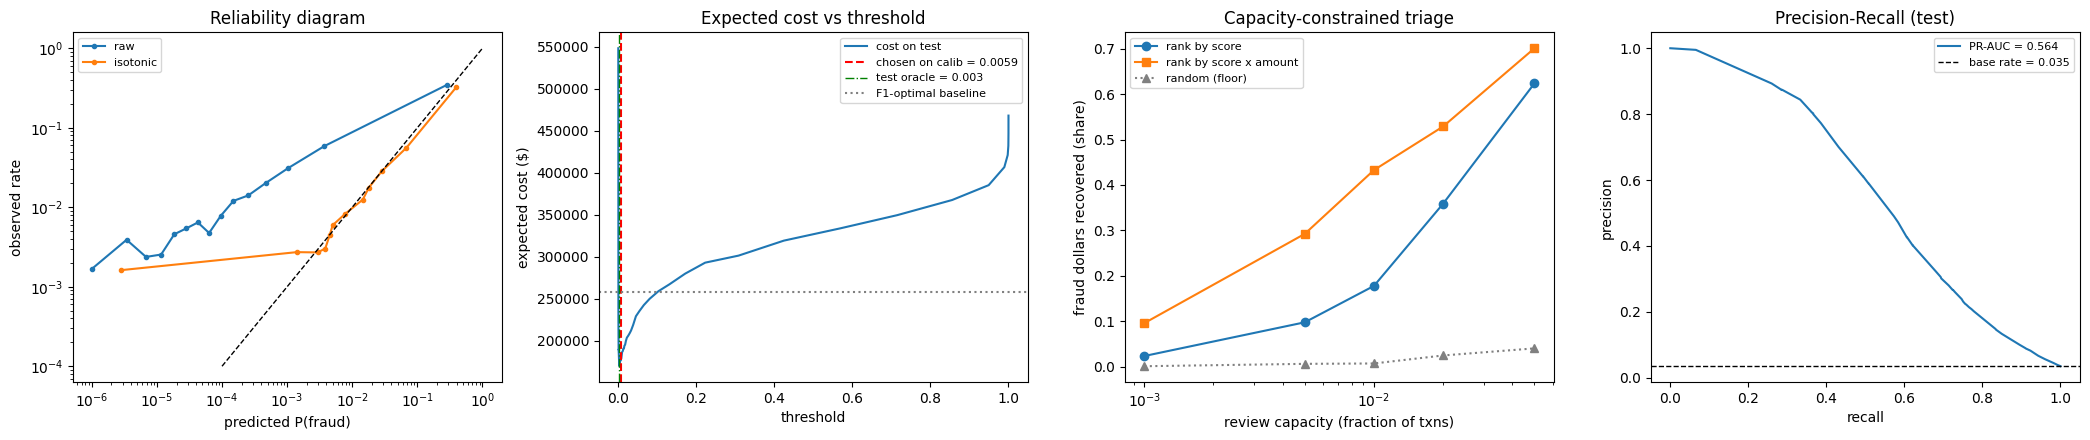


[out] /content/results/results.json, figures.png, model.txt, feature_importance.csv


In [38]:
imp = pd.DataFrame({"feature": model.feature_name(),
                    "gain": model.feature_importance("gain")}
                   ).sort_values("gain", ascending=False)
imp.head(30).to_csv(f"{OUT_DIR}/feature_importance.csv", index=False)
results["top_features"] = imp["feature"].head(15).tolist()
print("[features] top 15 by gain:")
for f in results["top_features"]:
    print("   -", f)

fig, ax = plt.subplots(1, 4, figsize=(21, 4.5))

for key, lab in [("calibration_raw", "raw"), ("calibration_isotonic", "isotonic")]:
    b = results[key]["bins"]
    ax[0].plot([r["mean_pred"] for r in b], [r["observed"] for r in b],
               marker="o", ms=3, label=lab)
ax[0].plot([1e-4, 1], [1e-4, 1], "k--", lw=1)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("predicted P(fraud)"); ax[0].set_ylabel("observed rate")
ax[0].set_title("Reliability diagram"); ax[0].legend(fontsize=8)

ax[1].plot(grid, costs, label="cost on test")
ax[1].axvline(t_raw_star,   color="r", ls="--",  label=f"chosen on calib = {t_raw_star:.4f}")
ax[1].axvline(t_oracle, color="g", ls="-.", lw=1, label=f"test oracle = {t_oracle:.3f}")
ax[1].axhline(c_f1, color="gray", ls=":", label="F1-optimal baseline")
ax[1].set_xlabel("threshold"); ax[1].set_ylabel("expected cost ($)")
ax[1].set_title("Expected cost vs threshold"); ax[1].legend(fontsize=8)

fr = [r["capacity_frac"] for r in cap]
ax[2].plot(fr, [r["score_recall_dollars"] for r in cap], marker="o", label="rank by score")
ax[2].plot(fr, [r["ev_recall_dollars"] for r in cap], marker="s", label="rank by score x amount")
ax[2].plot(fr, [r["random_dollars_recovered"]/total_fraud for r in cap],
           marker="^", ls=":", color="gray", label="random (floor)")
ax[2].set_xscale("log"); ax[2].set_xlabel("review capacity (fraction of txns)")
ax[2].set_ylabel("fraud dollars recovered (share)")
ax[2].set_title("Capacity-constrained triage"); ax[2].legend(fontsize=8)

pr, rc, _ = precision_recall_curve(y[te], cal_te)
ax[3].plot(rc, pr, label=f"PR-AUC = {results['pr_auc']:.3f}")
ax[3].axhline(y[te].mean(), color="k", ls="--", lw=1,
              label=f"base rate = {y[te].mean():.3f}")
ax[3].set_xlabel("recall"); ax[3].set_ylabel("precision")
ax[3].set_title("Precision-Recall (test)"); ax[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures.png", dpi=140, bbox_inches="tight")
plt.show()

with open(f"{OUT_DIR}/results.json", "w") as fh:
    json.dump(results, fh, indent=2)
model.save_model(f"{OUT_DIR}/model.txt")
print(f"\n[out] {OUT_DIR}/results.json, figures.png, model.txt, feature_importance.csv")

# resume line and download

In [39]:
th = results["threshold"]
print(f"""
Cost-sensitive fraud detection on {results['n_test']:,} held-out transactions
({results['test_fraud_rate']*100:.1f}% positive, temporal split); expected-cost-optimal
thresholding with isotonic calibration under a review-capacity constraint,
cutting simulated net loss {th['savings_vs_f1_pct']:.0f}% vs. a cost-blind F1-optimal
threshold at p99 latency of {results['latency']['p99_ms']:.0f}ms.
PR-AUC {results['pr_auc']:.3f} | ECE {results['calibration_raw']['ece']:.4f} ->
{results['calibration_isotonic']['ece']:.4f} | oracle gap {th['oracle_gap_pct']:.1f}%.
""")

from google.colab import files
!cd /content && zip -qr results.zip results
files.download("/content/results.zip")


Cost-sensitive fraud detection on 88,581 held-out transactions
(3.5% positive, temporal split); expected-cost-optimal
thresholding with isotonic calibration under a review-capacity constraint,
cutting simulated net loss 31% vs. a cost-blind F1-optimal
threshold at p99 latency of 43ms.
PR-AUC 0.564 | ECE 0.0154 ->
0.0065 | oracle gap 4.6%.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>